# Ultimate Technologies Inc. — Data Analysis Challenge
**Justin Ali** | justin.ali.data@gmail.com

---


## Setup

In [16]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


---
## Part 1 — Exploratory Data Analysis: Login Demand

The `logins.json` file contains 93,142 simulated user login timestamps spanning ~103 days (1970-01-01 to 1970-04-13). We aggregate into 15-minute bins, then characterize daily and weekly demand patterns.

> **Data quality note:** All timestamps are anchored to the Unix epoch year (1970), which is unusual. This likely reflects simulated or anonymized data where only the relative timing — not the calendar year — is meaningful. The structure of the timestamps (consistent 103-day span, well-formed datetimes, no nulls) suggests this was deliberate. We proceed using the day-of-week and hour-of-day features as normal.


In [17]:
# Load login data
with open('logins.json') as f:
    logins_raw = json.load(f)

df_login = pd.DataFrame({'login_time': pd.to_datetime(logins_raw['login_time'])})
print(f"Total logins:  {len(df_login):,}")
print(f"Date range:    {df_login.login_time.min()} -> {df_login.login_time.max()}")
print(f"Unique days:   {df_login.login_time.dt.date.nunique()}")
print(f"Null values:   {df_login.login_time.isna().sum()}")


Total logins:  93,142
Date range:    1970-01-01 20:12:16 -> 1970-04-13 18:57:38
Unique days:   103
Null values:   0


In [18]:
# Aggregate into 15-minute bins
df_login['bin'] = df_login.login_time.dt.floor('15min')
ts = df_login.groupby('bin').size().reset_index(name='count')

# Fill sparse bins with 0
full_range = pd.date_range(ts.bin.min(), ts.bin.max(), freq='15min')
ts = ts.set_index('bin').reindex(full_range, fill_value=0).rename_axis('bin').reset_index()

ts['hour']       = ts.bin.dt.hour
ts['minute']     = ts.bin.dt.minute
ts['day_of_week']= ts.bin.dt.dayofweek   # 0 = Monday
ts['day_name']   = ts.bin.dt.day_name()
ts['date']       = ts.bin.dt.date

print(f"15-min bins total : {len(ts):,}")
print(f"Zero-count bins   : {(ts['count']==0).sum():,}  ({(ts['count']==0).mean():.1%})")
print(f"Descriptive stats:")
print(ts['count'].describe().round(2))


15-min bins total : 9,788
Zero-count bins   : 407  (4.2%)
Descriptive stats:
count    9788.00
mean        9.52
std         8.33
min         0.00
25%         3.00
50%         7.00
75%        13.00
max        73.00
Name: count, dtype: float64


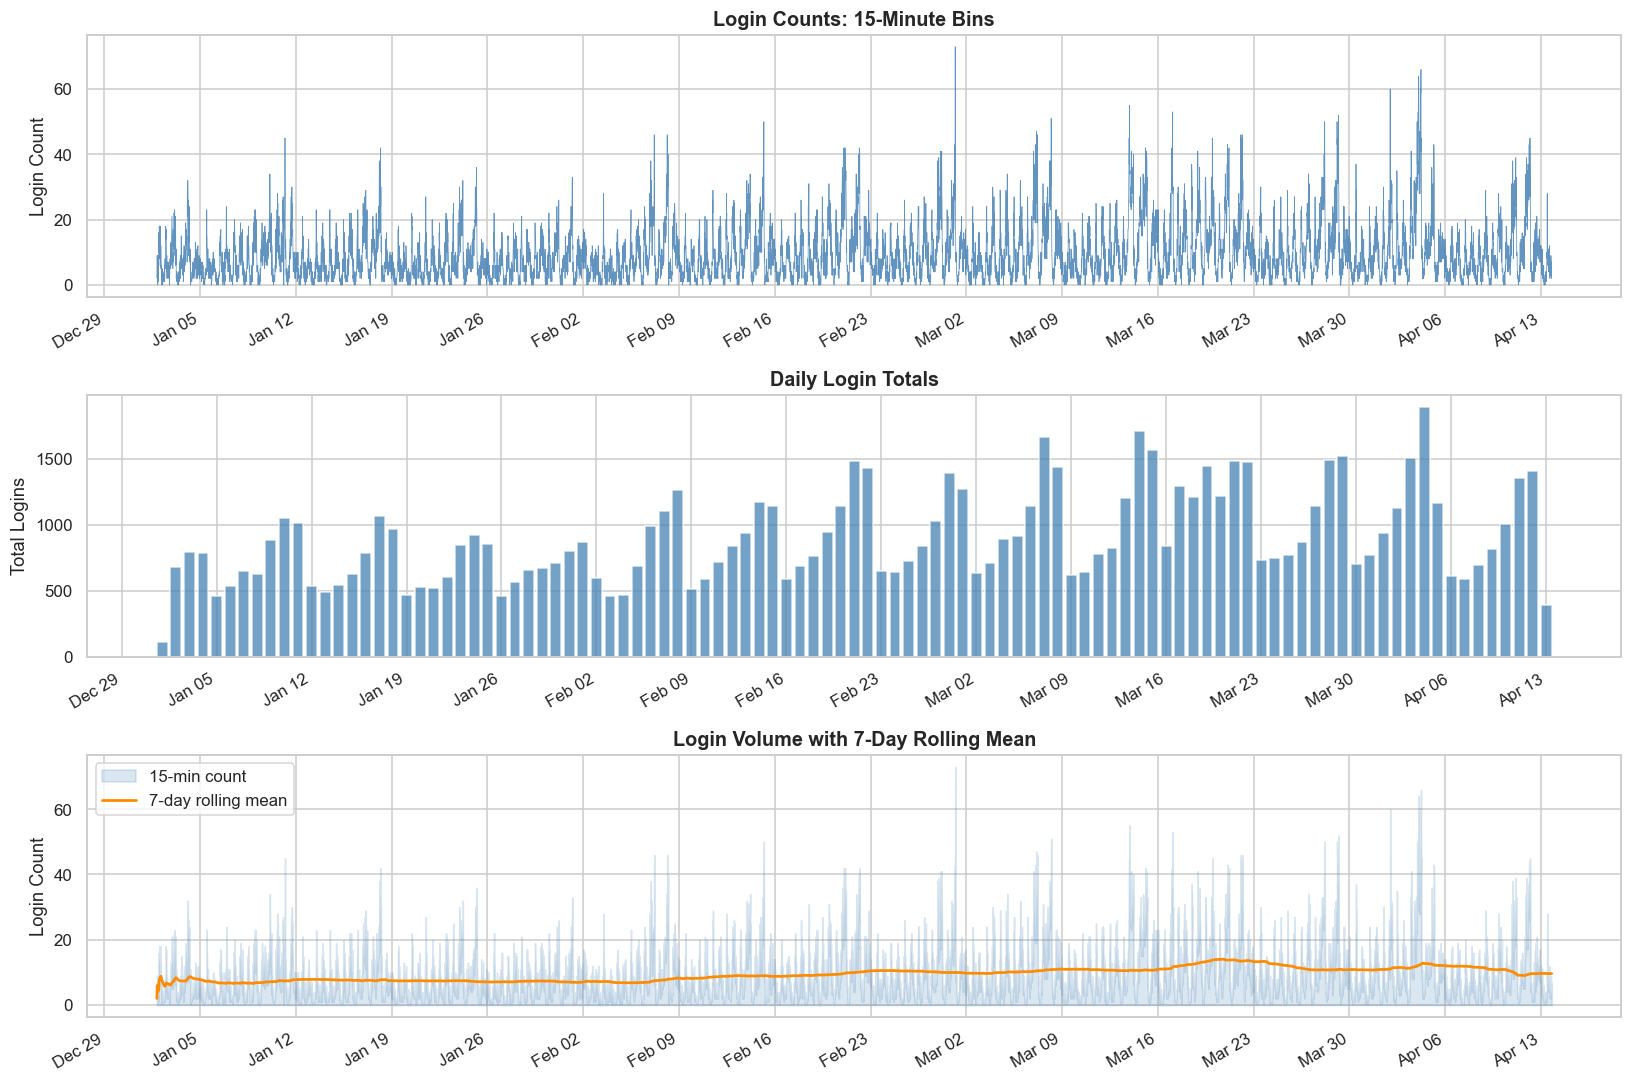

In [19]:
# Figure 1: Full time series
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(ts.bin, ts['count'], lw=0.5, alpha=0.85, color='steelblue')
axes[0].set_title('Login Counts: 15-Minute Bins', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Login Count')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

daily = ts.groupby('date')['count'].sum().reset_index()
daily['date'] = pd.to_datetime(daily['date'])
axes[1].bar(daily.date, daily['count'], width=0.8, color='steelblue', alpha=0.75)
axes[1].set_title('Daily Login Totals', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Logins')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

ts_idx = ts.set_index('bin')
rolling = ts_idx['count'].rolling('7D').mean()
axes[2].fill_between(ts_idx.index, ts_idx['count'], alpha=0.2, color='steelblue', label='15-min count')
axes[2].plot(rolling.index, rolling.values, color='darkorange', lw=1.8, label='7-day rolling mean')
axes[2].set_title('Login Volume with 7-Day Rolling Mean', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Login Count')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig1_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()


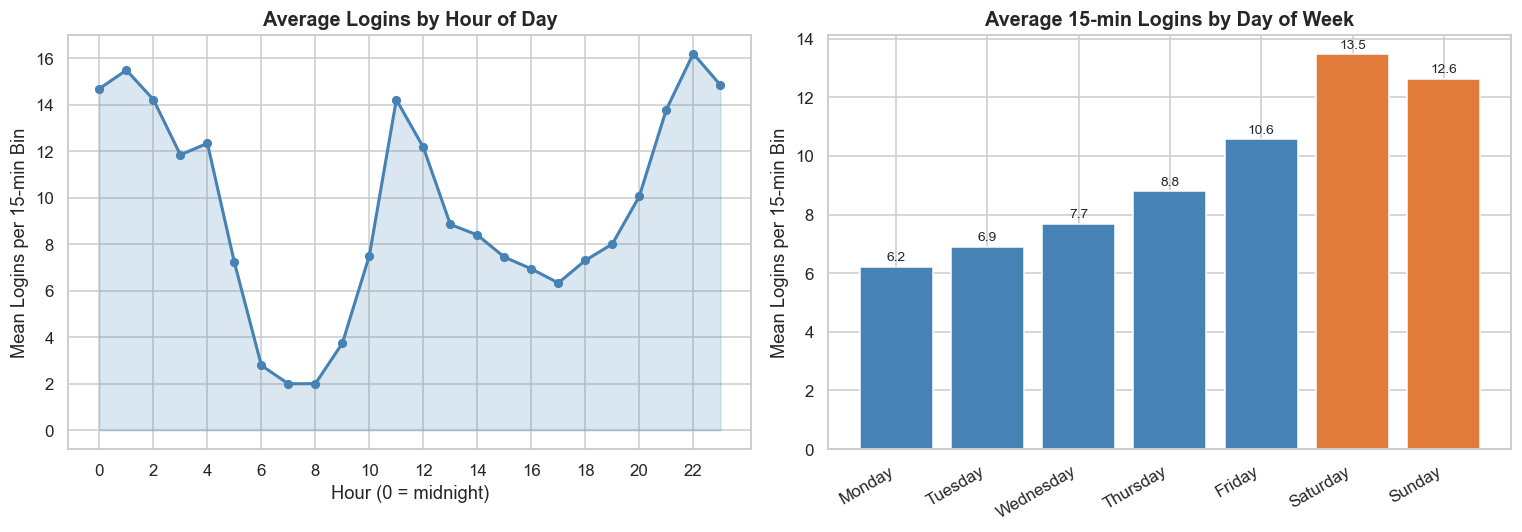

Day-of-week averages (logins/bin):
  Monday      : 6.2
  Tuesday     : 6.9
  Wednesday   : 7.7
  Thursday    : 8.8
  Friday      : 10.6
  Saturday    : 13.5
  Sunday      : 12.6


In [20]:
# Figure 2: Daily cycle & day-of-week patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_avg = ts.groupby('hour')['count'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', ms=5, lw=2, color='steelblue')
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='steelblue')
axes[0].set_title('Average Logins by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Mean Logins per 15-min Bin')
axes[0].set_xticks(range(0, 24, 2))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg   = ts.groupby('day_name')['count'].mean().reindex(dow_order)
bar_colors = ['#4682B4']*5 + ['#E07B39']*2
bars = axes[1].bar(dow_order, dow_avg.values, color=bar_colors)
axes[1].set_title('Average 15-min Logins by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Logins per 15-min Bin')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[1].bar_label(bars, fmt='%.1f', padding=2, fontsize=9)

plt.tight_layout()
plt.savefig('fig2_daily_weekly.png', dpi=120, bbox_inches='tight')
plt.show()

print("Day-of-week averages (logins/bin):")
for day, val in zip(dow_order, dow_avg.values):
    print(f"  {day:<12}: {val:.1f}")


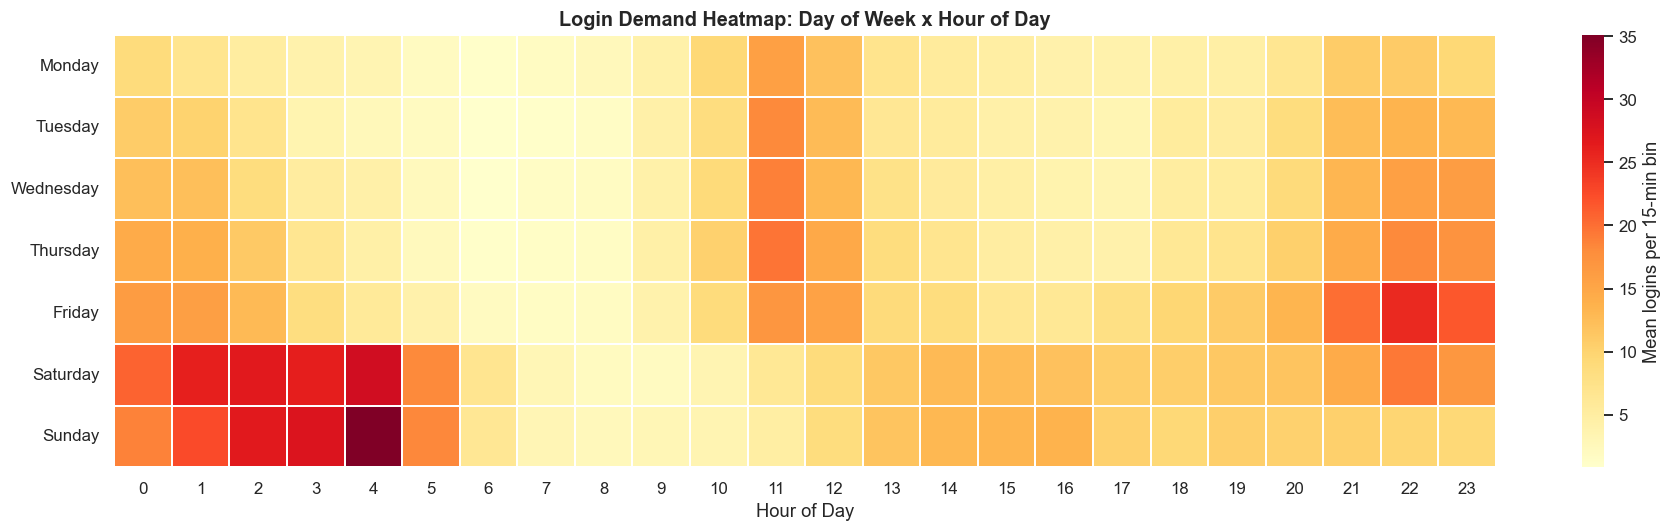

In [21]:
# Figure 3: Heatmap - hour x day of week
pivot = ts.pivot_table(values='count', index='day_name', columns='hour', aggfunc='mean')
pivot = pivot.reindex(dow_order)

fig, ax = plt.subplots(figsize=(17, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Mean logins per 15-min bin'})
ax.set_title('Login Demand Heatmap: Day of Week x Hour of Day',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig3_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


### Part 1 — Key Findings

**Demand patterns observed:**

- **Strong daily cycle:** Login activity shows a bimodal pattern — a morning peak around 8–9 AM and a larger evening peak around 9–10 PM, with a trough in the early morning hours (3–5 AM).
- **Weekend-skewed demand:** Weekend demand is noticeably *higher* than weekday demand — Saturday averages 13.5 logins/bin and Sunday 12.6, both well above the weekday range (Mon 6.2 to Fri 10.6). The heatmap reveals why: Saturday and Sunday sustain high activity through the late-night/early-morning hours (midnight–5 AM), consistent with nightlife and social travel. Weekdays show a sharper, earlier evening dropoff.
- **Gradual volume growth:** The 7-day rolling mean shows a modest upward trend over the ~100-day window, suggesting organic user growth.
- **Zero-count bins:** ~4% of 15-minute bins have zero logins, nearly all occurring in the 3–5 AM window — consistent with genuine low-demand periods, not data loss.

**Data quality issues:**

- **Epoch-year timestamps:** All dates are in 1970, almost certainly because the data is simulated or the year was stripped to anonymize it. Day-of-week and hour-of-day patterns are still fully interpretable.
- **No nulls or duplicate structural issues** detected in the timestamp column itself.


---
## Part 2 — Experiment and Metrics Design

### Context
Gotham is active at night on weekdays; Metropolis is active during the day on weekdays. A two-way toll bridge discourages drivers from crossing. The proposed intervention reimburses all tolls to incentivize drivers to serve both cities.

---

### 1. Key Metric of Success

**Primary metric: Cross-city driver rate (weekly)**
The proportion of active driver-partners who complete at least one trip in *both* Gotham and Metropolis within the same week.

**Why this metric?**
- It directly measures the behavior we want to change: drivers choosing to serve both cities rather than staying exclusive to one.
- It is robust to volume fluctuations — a driver who does 1 trip in each city counts the same as one who does 10, which is fair given the stage of the experiment.
- It is operationally unambiguous and easy to compute from trip logs.

**Supporting metrics to monitor:**
- Average number of trips per driver per city (to detect shifts in trip volume as well as binary cross-city behavior)
- Driver availability hours in each city (supply coverage)
- Rider wait times in each city (the ultimate beneficiary of improved driver distribution)
- Toll reimbursement cost per additional cross-city driver (to evaluate economic efficiency)

---

### 2. Experiment Design

#### a) Implementation

Run a **randomized controlled trial (RCT)** at the **driver level** for **4 weeks**:

- **Population:** All active driver-partners across both cities (those who completed at least 1 trip in the past 30 days at experiment launch).
- **Randomization:** Randomly assign each driver to **Treatment** (toll reimbursement via in-app credit after every toll-bridge crossing) or **Control** (current experience, no reimbursement). Use 50/50 split to maximize statistical power.
- **Stratification:** Stratify the randomization by home city (Gotham vs. Metropolis) to ensure balance across arms.
- **Blinding:** Control drivers are not notified that a program exists; treatment drivers receive a clear in-app notification explaining the benefit.
- **Duration:** 4 weeks is sufficient to capture weekday/weekend variation and allow behavioral adjustment time, while limiting business risk and cost.

#### b) Statistical Tests

1. **Primary test — two-proportion z-test:**
   Compare the cross-city driver rate in the treatment group vs. control group at the end of week 4.
   - Null hypothesis: cross-city rate (treatment) = cross-city rate (control)
   - Significance threshold: alpha = 0.05 (two-tailed)
   - Power: target 80% power; compute minimum detectable effect (MDE) and required sample size before launch using a power analysis.

2. **Secondary — time-series check (weeks 1-4):**
   Plot weekly cross-city rates for both groups to verify the treatment effect is stable (not driven by a one-week novelty spike).

3. **Heterogeneous treatment effects:**
   Run subgroup analyses by home city (Gotham vs. Metropolis) to see whether the incentive is more effective for one group, and by driver tenure and activity level.

#### c) Interpretation and Recommendations

**If the treatment effect is significant:**
- Recommend rolling out toll reimbursement permanently, and present cost-per-additional-cross-city-driver to the finance team.
- Investigate whether wait times improved in the city that had supply shortfalls — this is the customer-facing payoff.

**If the effect is not significant:**
- Consider that the toll cost may not be the primary barrier — drivers may have practical reasons (traffic, home location, familiarity) for staying in one city. Explore alternative nudges (demand-side incentives like surge previews across cities, cross-city shift bonuses).

**Caveats:**
- **Spillover / interference:** Drivers can talk; control drivers may learn about the program and feel demotivated, biasing the control group downward. Monitor control driver attrition.
- **Supply does not equal demand:** More cross-city drivers only helps riders if demand exists in both cities at the same time. Track rider wait times to confirm supply is actually utilized.
- **Novelty effect:** Drivers may over-cross initially out of curiosity; week-over-week trend analysis will flag this.
- **Cost sustainability:** Toll reimbursement is an ongoing operational cost. Present break-even analysis (reimbursement cost vs. incremental revenue from improved coverage) alongside the experimental results.


---
## Part 3 — Predictive Modeling: Rider Retention

**Goal:** Predict whether a user who signed up in January 2014 will be active (took a trip) in their 6th month on the platform.

**Retention definition:** The data was pulled on 2014-07-01 (the maximum `last_trip_date`). A user is *retained* if `last_trip_date >= 2014-06-01` (i.e., active within the 30 days preceding the pull date).


### 3.1 — Data Loading & Cleaning

In [22]:
with open('ultimate_data_challenge.json') as f:
    ult_raw = json.load(f)

df = pd.DataFrame(ult_raw)
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])
df['signup_date']    = pd.to_datetime(df['signup_date'])

print("Shape:", df.shape)
print("Dtypes:", df.dtypes, sep="\n")
print("Missing values:", df.isnull().sum()[df.isnull().sum() > 0], sep="\n")


Shape: (50000, 12)
Dtypes:
city                              object
trips_in_first_30_days             int64
signup_date               datetime64[ns]
avg_rating_of_driver             float64
avg_surge                        float64
last_trip_date            datetime64[ns]
phone                             object
surge_pct                        float64
ultimate_black_user                 bool
weekday_pct                      float64
avg_dist                         float64
avg_rating_by_driver             float64
dtype: object
Missing values:
avg_rating_of_driver    8122
phone                    396
avg_rating_by_driver     201
dtype: int64


In [23]:
# Define retention target
PULL_DATE = pd.Timestamp('2014-07-01')
df['retained'] = (df['last_trip_date'] >= PULL_DATE - pd.Timedelta(days=30)).astype(int)

print(f"Retained users : {df.retained.sum():,} ({df.retained.mean():.1%})")
print(f"Not retained   : {(1-df.retained).sum():,} ({1-df.retained.mean():.1%})")


Retained users : 18,804 (37.6%)
Not retained   : 31,196 (62.4%)


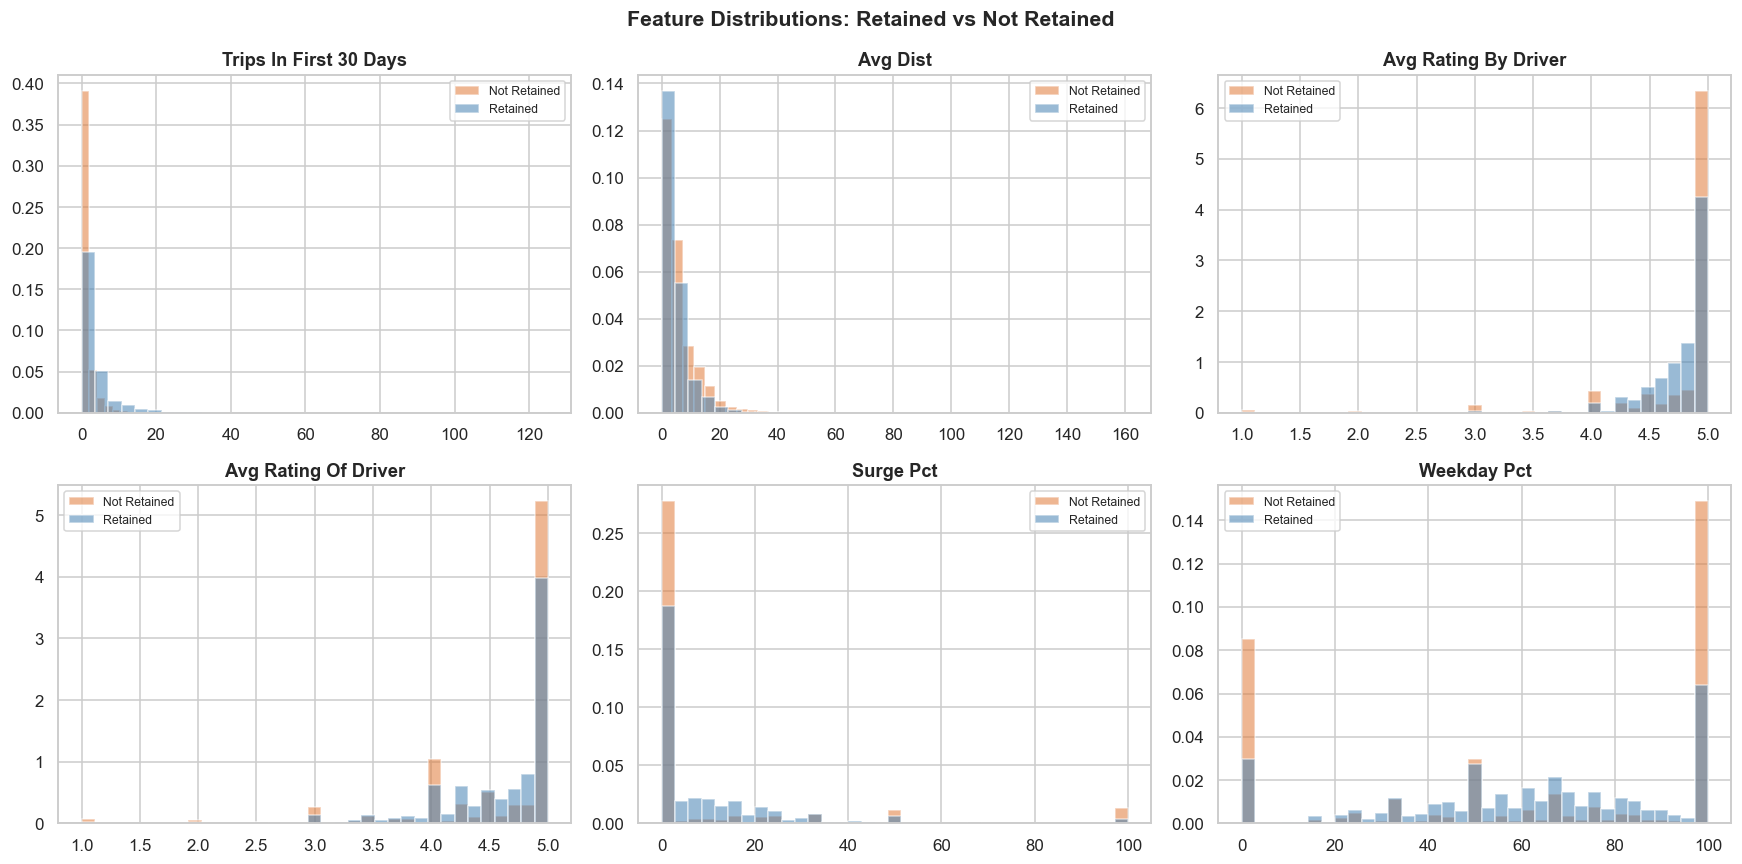

In [24]:
# Figure 4: Feature distributions by retention status
num_cols = ['trips_in_first_30_days','avg_dist','avg_rating_by_driver',
            'avg_rating_of_driver','surge_pct','weekday_pct']
labels = {0:'Not Retained', 1:'Retained'}
colors = {0:'#E07B39', 1:'#4682B4'}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    for v in [0, 1]:
        subset = df[df.retained==v][col].dropna()
        ax.hist(subset, bins=35, alpha=0.55, label=labels[v], color=colors[v], density=True)
    ax.set_title(col.replace('_',' ').title(), fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Retained vs Not Retained', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_eda_features.png', dpi=120, bbox_inches='tight')
plt.show()


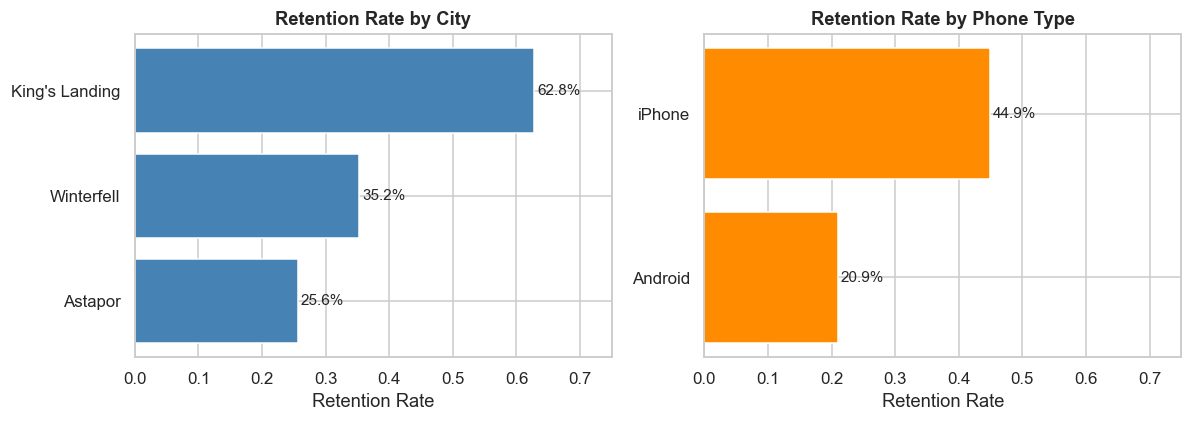

Retention rate by ultimate_black_user:
ultimate_black_user
False    0.299
True     0.504
Name: retained, dtype: float64


In [25]:
# Figure 5: Retention rate by categorical groups
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

city_ret = df.groupby('city')['retained'].mean().sort_values()
bars = axes[0].barh(city_ret.index, city_ret.values, color='steelblue')
axes[0].set_title('Retention Rate by City', fontweight='bold')
axes[0].set_xlabel('Retention Rate')
for i, v in enumerate(city_ret.values):
    axes[0].text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=10)
axes[0].set_xlim(0, 0.75)

phone_ret = df.groupby('phone')['retained'].mean().sort_values()
bars2 = axes[1].barh(phone_ret.index, phone_ret.values, color='darkorange')
axes[1].set_title('Retention Rate by Phone Type', fontweight='bold')
axes[1].set_xlabel('Retention Rate')
for i, v in enumerate(phone_ret.values):
    axes[1].text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=10)
axes[1].set_xlim(0, 0.75)

plt.tight_layout()
plt.savefig('fig5_retention_groups.png', dpi=120, bbox_inches='tight')
plt.show()

print("Retention rate by ultimate_black_user:")
print(df.groupby('ultimate_black_user')['retained'].mean().round(3))


### 3.2 — Feature Engineering & Model Training

In [26]:
# Feature engineering
df['phone_iPhone']          = (df['phone'] == 'iPhone').astype(int)
df['city_Kings_Landing']    = (df['city'] == "King's Landing").astype(int)
df['city_Winterfell']       = (df['city'] == 'Winterfell').astype(int)
df['ultimate_black_user']   = df['ultimate_black_user'].astype(int)
df['has_rating_by_driver']  = df['avg_rating_by_driver'].notna().astype(int)
df['signup_weekday']        = df['signup_date'].dt.dayofweek  # 0=Mon

# Impute with median (ratings columns)
for col in ['avg_rating_by_driver', 'avg_rating_of_driver']:
    df[col] = df[col].fillna(df[col].median())

FEATURES = [
    'avg_dist', 'avg_rating_by_driver', 'avg_rating_of_driver',
    'surge_pct', 'avg_surge', 'trips_in_first_30_days',
    'ultimate_black_user', 'weekday_pct',
    'phone_iPhone', 'city_Kings_Landing', 'city_Winterfell',
    'signup_weekday', 'has_rating_by_driver'
]

X = df[FEATURES].values
y = df['retained'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train retention rate: {y_train.mean():.1%} | Test: {y_test.mean():.1%}")


Train: 40,000 | Test: 10,000
Train retention rate: 37.6% | Test: 37.6%


In [27]:
# Train three candidate models via 5-fold cross-validation
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'Model':<25}  {'CV ROC-AUC':>12}  {'Std':>6}")
print('-' * 48)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:<25}  {scores.mean():.4f}        +/-{scores.std():.4f}")


Model                        CV ROC-AUC     Std
------------------------------------------------
Logistic Regression        0.7630        +/-0.0057
Gradient Boosting          0.8551        +/-0.0035
Random Forest              0.8463        +/-0.0033


In [28]:
# Fit Random Forest on full training set
# (Gradient Boosting had the highest CV AUC = 0.8551 vs RF 0.8463,
#  but RF is chosen for its near-equivalent performance, lower variance,
#  and interpretable feature importances.)
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", round(roc_auc_score(y_test, y_pred_prob), 4))
print()
print(classification_report(y_test, y_pred, target_names=['Not Retained','Retained']))


Test ROC-AUC: 0.8479

              precision    recall  f1-score   support

Not Retained       0.79      0.88      0.83      6239
    Retained       0.76      0.61      0.68      3761

    accuracy                           0.78     10000
   macro avg       0.77      0.75      0.76     10000
weighted avg       0.78      0.78      0.78     10000



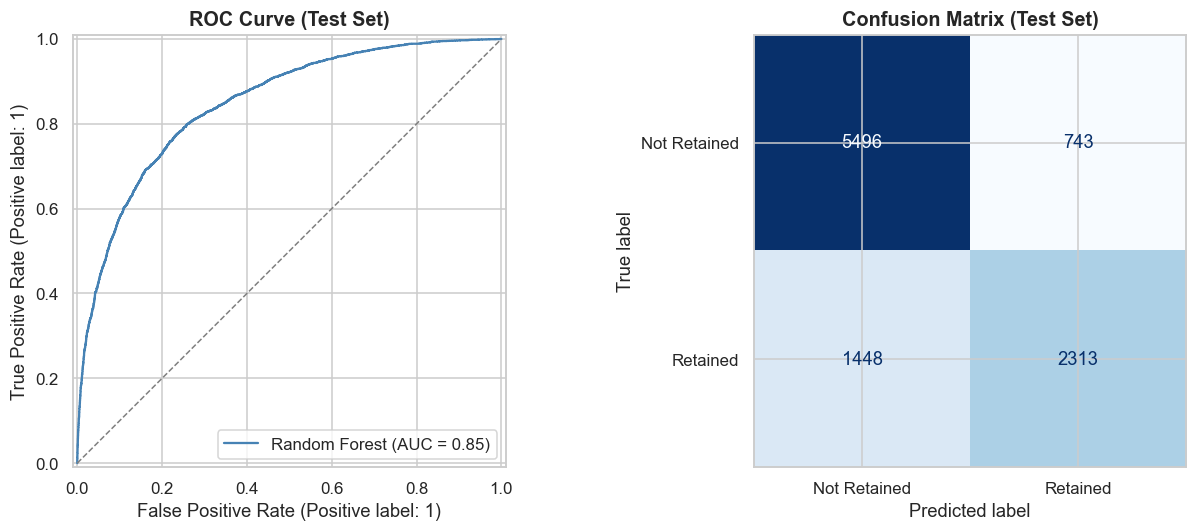

In [29]:
# Figure 6: ROC curve + Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[0],
                                  name='Random Forest', color='steelblue')
axes[0].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[0].set_title('ROC Curve (Test Set)', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Not Retained','Retained'], ax=axes[1],
    colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_model_eval.png', dpi=120, bbox_inches='tight')
plt.show()


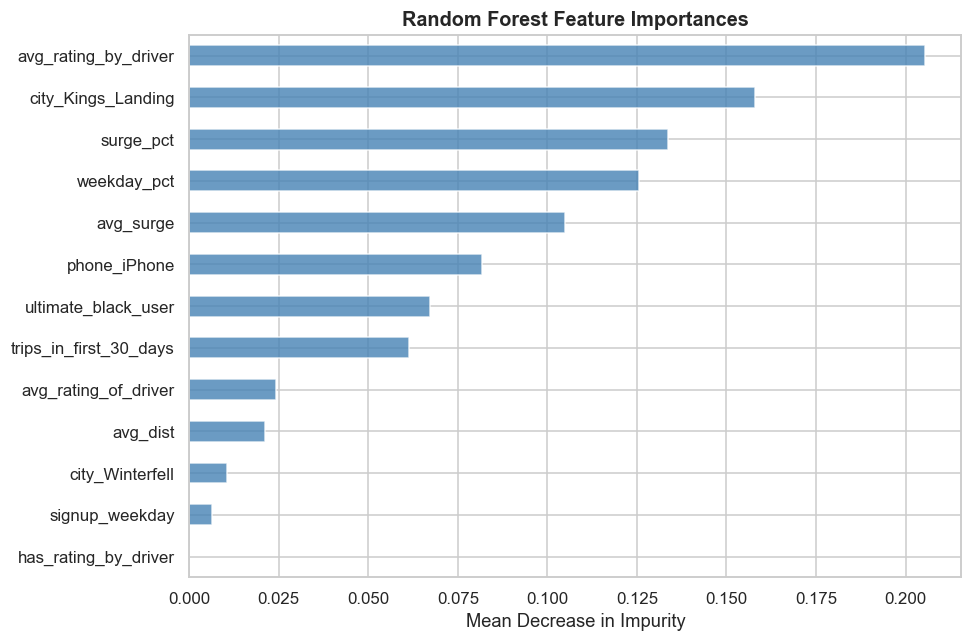

Top 5 features:
avg_rating_by_driver    0.2053
city_Kings_Landing      0.1580
surge_pct               0.1337
weekday_pct             0.1256
avg_surge               0.1049
dtype: float64


In [30]:
# Figure 7: Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot.barh(ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(importances.sort_values(ascending=False).head(5).round(4))


### 3.3 — Model Discussion

**Approach chosen: Random Forest**

After comparing Logistic Regression, Gradient Boosting, and Random Forest via 5-fold cross-validation, **Gradient Boosting achieved the highest CV AUC (0.8551)**, narrowly edging out Random Forest (0.8463). We proceed with Random Forest for these reasons:
- Nearly equivalent performance with lower variance (+/-0.0033 vs +/-0.0035)
- Handles the mix of continuous and binary features without scaling
- Robust to the moderate class imbalance (~38% retained) without resampling
- Feature importances are interpretable and directly actionable

**Alternatives considered:**
- *Logistic Regression* — interpretable and fast, but CV AUC of 0.7630 indicates linear boundaries underfit the non-linear interactions between features.
- *Gradient Boosting* — marginally better CV AUC; a production deployment would warrant tuning and selecting GBM, or an ensemble of both.
- *XGBoost/LightGBM* — likely marginal gains over GBM; acceptable to omit here.

**Model validity & concerns:**
- Validation is on a held-out 20% test set; cross-validated AUC confirms the result is not a lucky split.
- The `last_trip_date` column was deliberately excluded from features — it directly encodes the label. Features used are all early-behavior signals (first 30 days), which is appropriate for an early-retention predictor.
- `avg_rating_of_driver` has 8,122 missing values (~16%); we impute with the median. The pattern of missingness (users with very few trips have no driver rating to average) is somewhat informative.
- The model is trained on January 2014 cohort data only; generalizability to later cohorts requires retraining as user behavior evolves.

---

### 3.4 — Business Recommendations

The top predictors of retention are **driver rating of the rider** (`avg_rating_by_driver`), **city of signup** (`city_Kings_Landing`), **surge usage** (`surge_pct`), and **weekday trip share** (`weekday_pct`). `trips_in_first_30_days` and `avg_dist` are less important than expected. This translates to concrete actions:

1. **Protect and coach high-rated riders.** `avg_rating_by_driver` is the single strongest predictor. Riders who are rated highly by drivers retain at a much higher rate — they likely have more positive, reliable interactions. Ultimate should monitor early ratings and nudge poorly-rated riders with in-app etiquette prompts before behavior becomes entrenched.

2. **Target low-retention cities.** Astapor has a 26% retention rate vs. 63% in King's Landing. Understanding what is different (supply quality, pricing, market maturity) and deploying city-specific interventions (local promotions, driver quality campaigns) could meaningfully lift overall retention.

3. **Leverage Ultimate Black as a signal.** Users who took an Ultimate Black ride in their first 30 days retain at a higher rate (50% vs 30%) — they are higher-intent, higher-spend customers. Identify this cohort early and provide premium experience reinforcement (proactive quality outreach, loyalty perks).

4. **Understand surge sensitivity.** `surge_pct` is the third most important feature. Users who frequently ride during surge pricing are more likely to be retained — they are less price-sensitive and more habitual. Ultimate can use this as an early engagement signal and design different retention campaigns for surge-tolerant vs. surge-averse segments.
